In [16]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Mac)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 데이터 로드 ──────────────────────────────────────────
df = pd.read_csv('data/active_jobs.csv')
has_desc = df[df['description'].notna() & (df['description'] != '')]
print(f'전체 공고: {len(df)}개')
print(f'description 보유: {len(has_desc)}개')
print(f'\n산업군별 공고 수:')
print(df['industry'].value_counts())

전체 공고: 430개
description 보유: 295개

산업군별 공고 수:
industry
이커머스·유통        102
IT·플랫폼·SaaS     67
금융·보험           48
미디어·콘텐츠         48
기타              46
헤드헌팅            39
헬스케어·바이오        31
교육              28
제조·모빌리티         19
공공기관             2
Name: count, dtype: int64


In [17]:
# ── 불용어 설정 ──────────────────────────────────────────
STOPWORDS = {
    '및', '의', '을', '를', '이', '가', '은', '는', '에', '에서', '으로', '로', '과', '와',
    '한', '하는', '하여', '하고', '있는', '있습니다', '합니다', '위한', '통해', '대한',
    '관련', '등', '수', '더', '또한', '이를', '이런', '이후', '함께', '기반', '활용',
    '업무', '경험', '분석', '데이터', '팀', '능력', '역량', '담당', '수행', '개발',
    '서비스', '기업', '회사', '고객', '사업', '운영', '관리', '지원', '결과', '통한',
    '위해', '내', '직무', '채용', '모집', '채용공고', '지원자', '담당자', '전문가',
    '이상', '이하', '가능', '필요', '보유', '우대', '자격', '요건', '우리', '저희',
    '경험이', '있으신', '보유하신', '데이터를', '활용한', '기반으로', '분석을', '문제를',
    '결과를', '인사이트를', '이상의', '가능한', '경험을', 'and', 'to', 'or', 'the',
    'of', 'in', 'for', 'with', 'Data', '또는', '분석가', '취소될', '채용이',
    '포지션', '자격요건', '발견될', '경우', '면접일정은', '추후', '통보됩니다', '최종합격'
}

def get_keywords(texts, top_n=20):
    words = []
    for desc in texts:
        ws = re.findall(r'[가-힣a-zA-Z\+\#]{2,}', str(desc))
        for w in ws:
            if w not in STOPWORDS and len(w) >= 2:
                words.append(w)
    return Counter(words).most_common(top_n)

def get_phrases(texts, top_n=20):
    phrases = []
    for desc in texts:
        text = re.sub(r'[\n\r•\-·]', ' ', str(desc))
        words = re.findall(r'[가-힣a-zA-Z\+\#]{2,}', text)
        for i in range(len(words)-1):
            p2 = words[i] + ' ' + words[i+1]
            if not all(w in STOPWORDS for w in p2.split()):
                phrases.append(p2)
    # 불필요한 구문 필터링
    filtered = [p for p in phrases if not any(
        w in p for w in ['취소될', '채용이', '포지션', '자격요건', '발견될', '면접일정', '추후', '통보']
    )]
    return Counter(filtered).most_common(top_n)
    

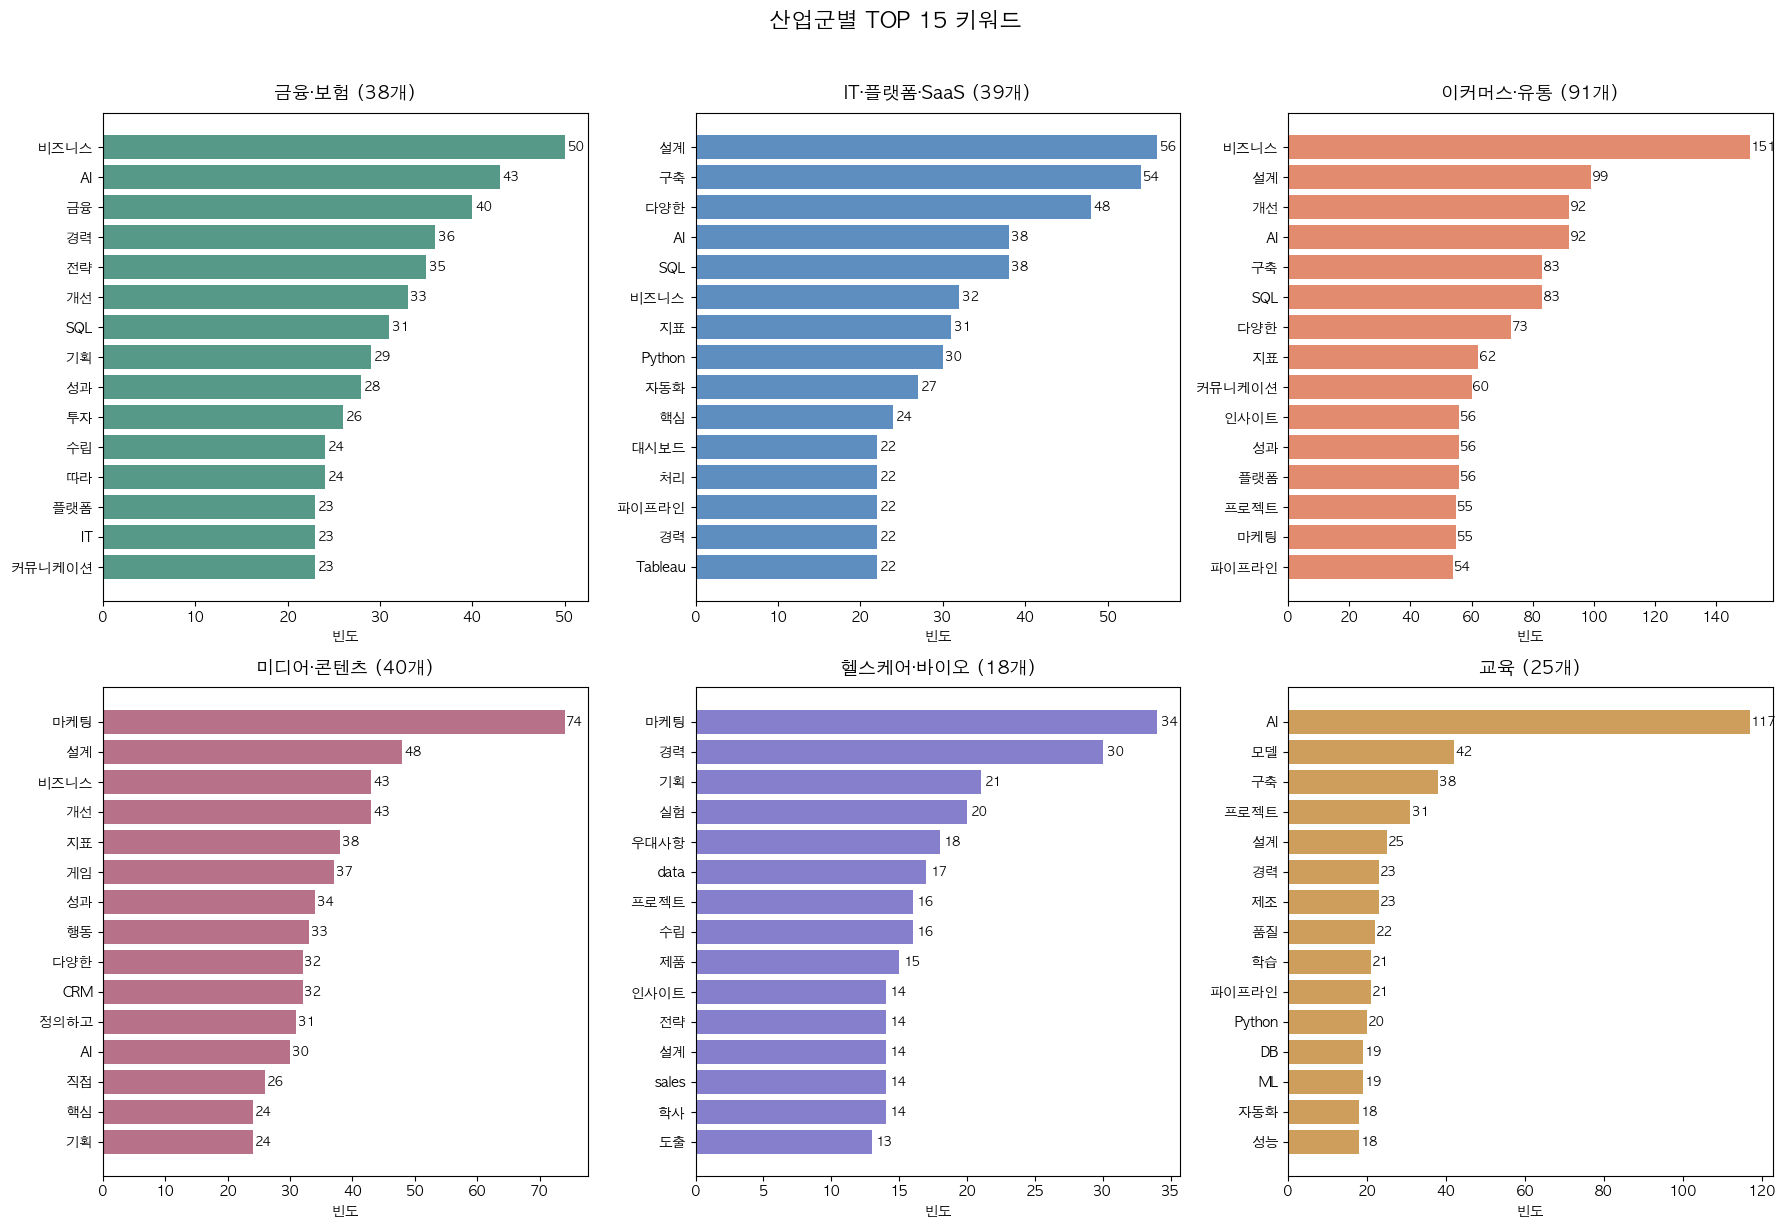

저장 완료!


In [6]:
# ── 산업군별 키워드 분석 ──────────────────────────────────────────
industries = {
    '금융·보험': '#0F6E56',
    'IT·플랫폼·SaaS': '#185FA5',
    '이커머스·유통': '#D85A30',
    '미디어·콘텐츠': '#993556',
    '헬스케어·바이오': '#534AB7',
    '교육': '#BA7517',
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (industry, color) in enumerate(industries.items()):
    subset = has_desc[has_desc['industry'] == industry]
    if len(subset) == 0:
        continue

    keywords = get_keywords(subset['description'], top_n=15)
    if not keywords:
        continue

    words, counts = zip(*keywords)
    ax = axes[idx]
    bars = ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.7)
    ax.set_title(f'{industry} ({len(subset)}개)', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('빈도', fontsize=10)
    ax.tick_params(axis='y', labelsize=10)

    for bar, count in zip(bars, list(counts)[::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=9)

plt.suptitle('산업군별 TOP 15 키워드', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/keyword_by_industry.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료!')


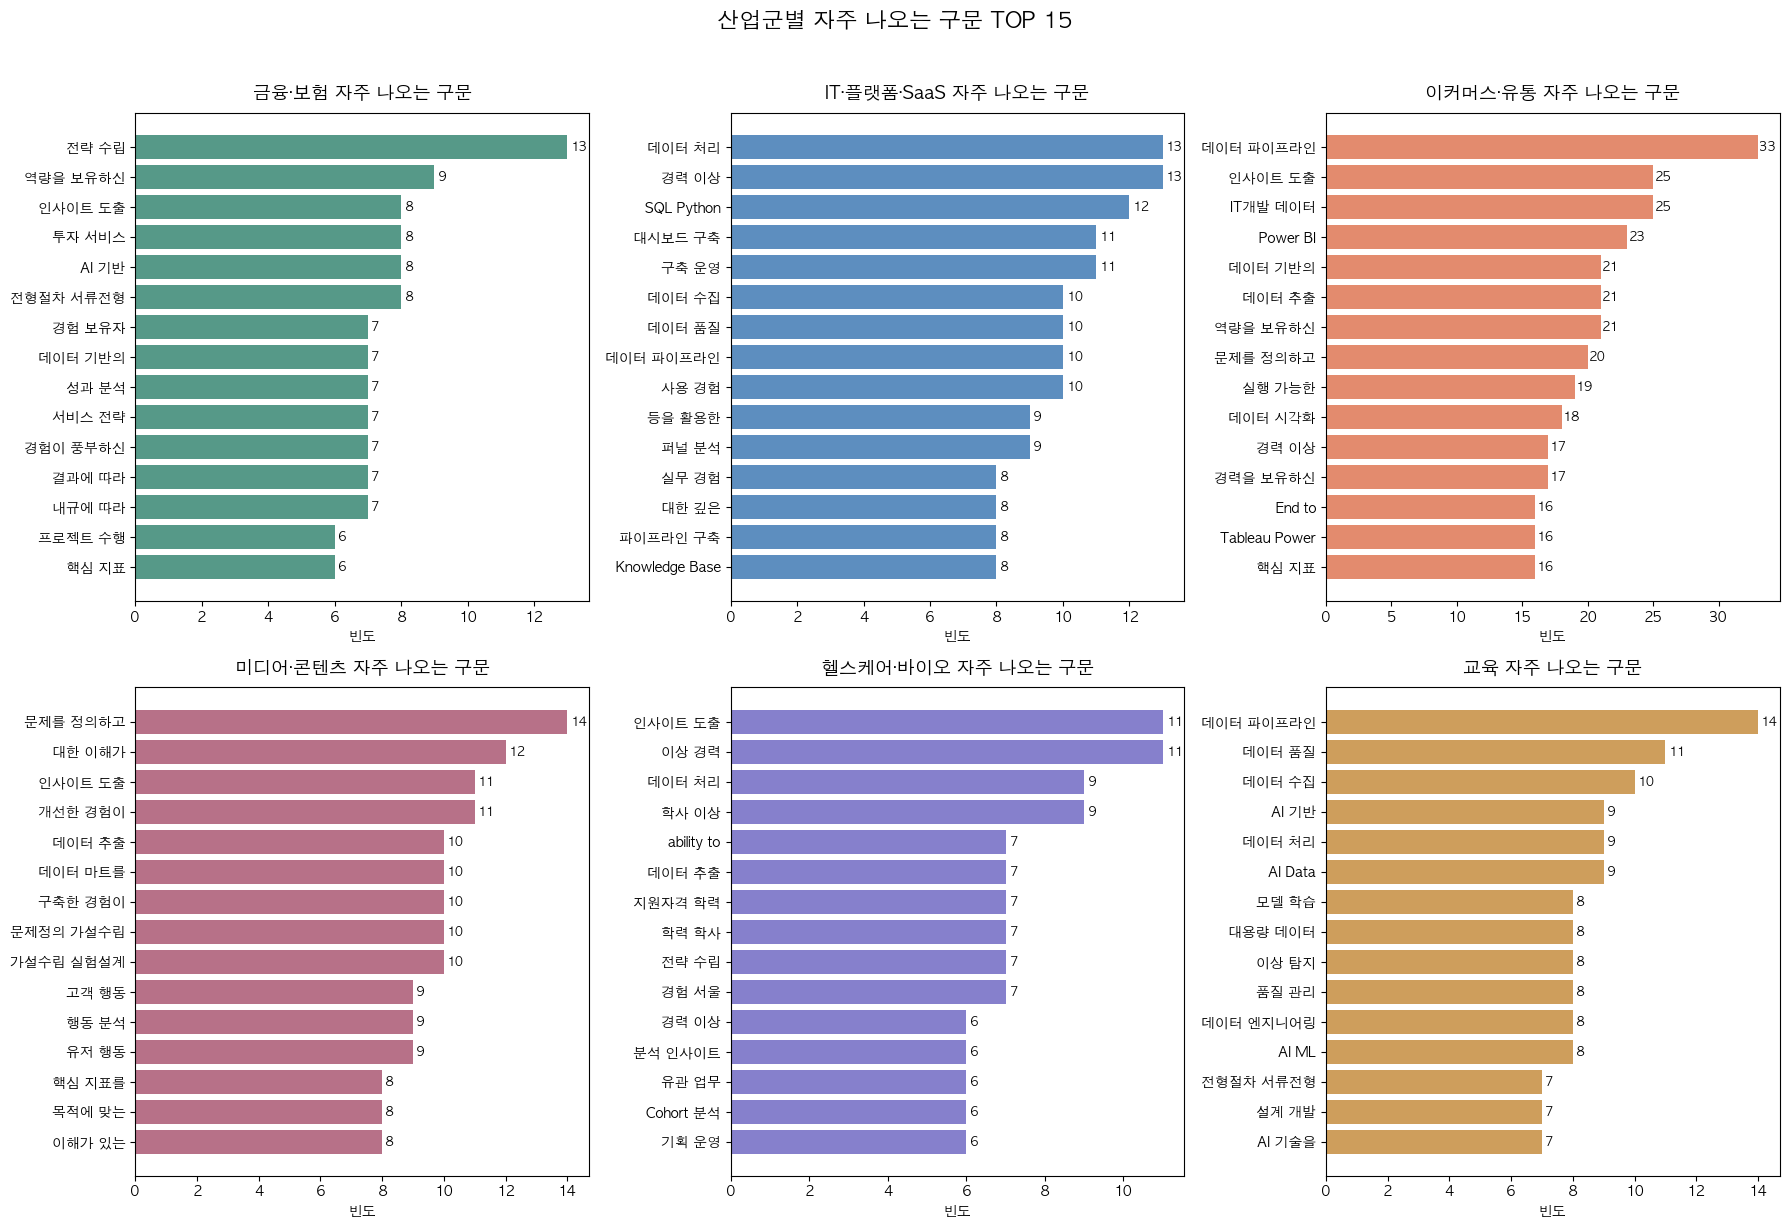

저장 완료!


In [18]:
# ── 산업군별 구문 분석 ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (industry, color) in enumerate(industries.items()):
    subset = has_desc[has_desc['industry'] == industry]
    if len(subset) == 0:
        continue

    phrases = get_phrases(subset['description'], top_n=15)
    if not phrases:
        continue

    words, counts = zip(*phrases)
    ax = axes[idx]
    bars = ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.7)
    ax.set_title(f'{industry} 자주 나오는 구문', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('빈도', fontsize=10)
    ax.tick_params(axis='y', labelsize=10)

    for bar, count in zip(bars, list(counts)[::-1]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=9)

plt.suptitle('산업군별 자주 나오는 구문 TOP 15', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/phrase_by_industry.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료!')

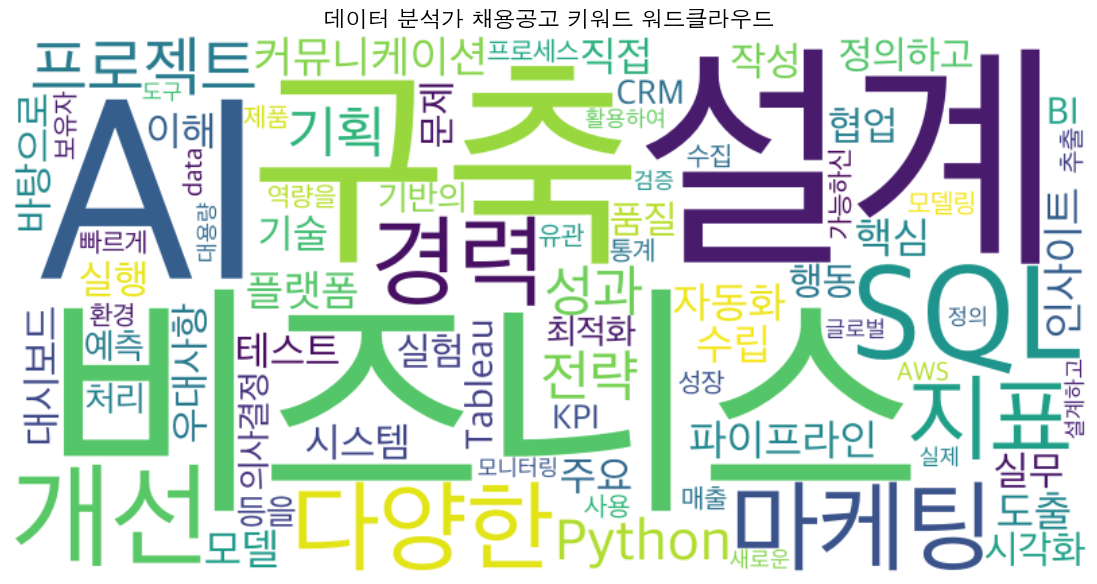

In [10]:
# ── 전체 워드클라우드 (선택) ──────────────────────────────────────────
from wordcloud import WordCloud

all_words = []
for desc in has_desc['description'].dropna():
    ws = re.findall(r'[가-힣a-zA-Z\+\#]{2,}', str(desc))
    for w in ws:
        if w not in STOPWORDS and len(w) >= 2:
            all_words.append(w)

word_freq = dict(Counter(all_words).most_common(100))

wc = WordCloud(
    font_path='/System/Library/Fonts/AppleSDGothicNeo.ttc',
    width=800, height=400,
    background_color='white',
    max_words=80,
    colormap='viridis'
).generate_from_frequencies(word_freq)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('데이터 분석가 채용공고 키워드 워드클라우드', fontsize=16, fontweight='bold')
plt.savefig('output/wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── 금융·보험 vs 전체 비교 ──────────────────────────────────────────
finance = has_desc[has_desc['industry'] == '금융·보험']
finance_kw = dict(get_keywords(finance['description'], top_n=20))
total_kw   = dict(get_keywords(has_desc['description'], top_n=20))

# 금융에서 전체 대비 많이 나오는 키워드
finance_unique = {k: v for k, v in finance_kw.items() if k not in total_kw or finance_kw[k] / len(finance) > total_kw.get(k, 0) / len(has_desc)}

print('=== 금융·보험에서 특히 많이 나오는 키워드 ===')
for k, v in sorted(finance_unique.items(), key=lambda x: x[1], reverse=True)[:15]:
    print(f'  {k}: {v}')


=== 금융·보험에서 특히 많이 나오는 키워드 ===
  AI: 55
  비즈니스: 52
  금융: 43
  전략: 37
  경력: 36
  개선: 34
  기획: 30
  성과: 28
  투자: 26
  플랫폼: 24
  IT: 24
  따라: 24
  수립: 23
  직접: 22
